In [1]:
import json
import pickle
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from IPython.display import display, Markdown


def find_project_root(start=None):
    path = Path.cwd() if start is None else Path(start)
    for candidate in [path, *path.parents]:
        if (candidate / "pipelines").exists() and (candidate / "spectral_code").exists():
            return candidate
    raise RuntimeError("Could not find Spectral-Software project root.")

PROJECT_ROOT = find_project_root()
BCB_DUMP = Path(r"C:\Users\koush\PyProjects\bcb")
OUTPUT_BASE = PROJECT_ROOT.parent / "outputs"
ANALYSIS_OUT = PROJECT_ROOT / "notebooks" / "analysis" / "outputs"
ANALYSIS_OUT.mkdir(parents=True, exist_ok=True)

DATASET_TYPES = [1, 2, 3, 4]
GRAPH_TYPES = ["ast", "cfg", "ddg", "pdg", "cpg"]


def type_paths(dataset_type):
    return {
        "bench_dir": PROJECT_ROOT / "bench_data" / f"bcb_full_type{dataset_type}",
        "output_root": OUTPUT_BASE / f"type{dataset_type}",
        "spectral_manifest": OUTPUT_BASE / f"type{dataset_type}" / "spectral_features" / "spectral_features_manifest.json",
    }


def available_dataset_types():
    available = []
    for dataset_type in DATASET_TYPES:
        paths = type_paths(dataset_type)
        if (paths["bench_dir"] / "train.txt").exists() and paths["spectral_manifest"].exists():
            available.append(dataset_type)
        else:
            print(f"Skipping Type {dataset_type}: missing train.txt or spectral manifest.")
    return available

AVAILABLE_TYPES = available_dataset_types()
print("Available dataset types:", AVAILABLE_TYPES)


def normalize_pair(left, right):
    left = int(left)
    right = int(right)
    return (left, right) if left <= right else (right, left)


def load_pairs(path):
    rows = []
    with Path(path).open("r", encoding="utf-8") as f:
        for line in f:
            left, right, label = line.strip().split("\t")
            rows.append((int(left), int(right), int(label)))
    return pd.DataFrame(rows, columns=["left_id", "right_id", "label"])


def iter_copy_table(dump_path, table_name, desc):
    dump_path = Path(dump_path)
    target_prefix = f"COPY {table_name} "
    in_table = False
    with dump_path.open("rb") as f, tqdm(total=dump_path.stat().st_size, unit="B", unit_scale=True, desc=desc) as bar:
        for raw in f:
            bar.update(len(raw))
            line = raw.decode("utf-8", errors="replace").rstrip("\n")
            if not in_table:
                if line.startswith(target_prefix):
                    in_table = True
                continue
            if line == r"\.":
                break
            yield line


def parse_float(raw):
    return None if raw == r"\N" or raw == "" else float(raw)


def load_clone_metadata_for_pair_keys(pair_keys, cache_path=None):
    pair_keys = set(pair_keys)
    if cache_path and Path(cache_path).exists():
        cached = pd.read_csv(cache_path)
        cached_keys = set(zip(cached.left_id.astype(int), cached.right_id.astype(int)))
        if pair_keys.issubset(cached_keys):
            return cached

    rows = []
    found = set()
    for line in iter_copy_table(BCB_DUMP, "public.clones", "Scanning BCB clone metadata"):
        parts = line.split("\t")
        if len(parts) < 7:
            continue
        key = normalize_pair(parts[0], parts[1])
        if key not in pair_keys or key in found:
            continue
        sim_line = parse_float(parts[5])
        sim_token = parse_float(parts[6])
        rows.append({
            "left_id": key[0],
            "right_id": key[1],
            "functionality_id": int(parts[2]),
            "bcb_type": parts[3],
            "syntactic_type": int(parts[4]),
            "similarity_line": sim_line,
            "similarity_token": sim_token,
            "min_similarity": min(sim_line, sim_token),
        })
        found.add(key)
        if len(found) == len(pair_keys):
            break

    missing = pair_keys - found
    if missing:
        print(f"Warning: {len(missing):,} pair keys were not found in public.clones.")
    meta = pd.DataFrame(rows)
    if cache_path:
        meta.to_csv(cache_path, index=False)
    return meta


def load_spectral_features_for_ids(dataset_type, method_ids):
    method_ids = {str(int(mid)) for mid in method_ids}
    manifest_path = type_paths(dataset_type)["spectral_manifest"]
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    features = {}
    for shard_path in tqdm(manifest["shards"], desc=f"Type {dataset_type}: spectral shards", unit="shard"):
        with open(shard_path, "rb") as f:
            shard = pickle.load(f)
        missing = method_ids - set(features)
        for method_id in list(missing):
            if method_id in shard:
                features[method_id] = shard[method_id]
        if len(features) == len(method_ids):
            break
    return features


def informative_eigenvalues(record, graph_type, eps=1e-10):
    if not record:
        return None
    values = np.asarray(record.get(graph_type, {}).get("eigenvalues", []), dtype=float)
    if values.size == 0 or not np.all(np.isfinite(values)) or not np.any(np.abs(values) > eps):
        return None
    return values


def node_count(record, graph_type):
    if not record:
        return np.nan
    return record.get(graph_type, {}).get("nodes", np.nan)


def pss(ev1, ev2):
    ev1 = np.asarray(ev1, dtype=float)
    ev2 = np.asarray(ev2, dtype=float)
    nz1 = np.nonzero(ev1)[0]
    nz2 = np.nonzero(ev2)[0]
    if len(nz1) == 0 or len(nz2) == 0:
        return np.nan
    ev1 = ev1[:nz1[-1] + 1]
    ev2 = ev2[:nz2[-1] + 1]
    max_len = max(len(ev1), len(ev2))
    if len(ev1) != max_len:
        ev1 = np.interp(np.linspace(0, 1, max_len), np.linspace(0, 1, len(ev1)), ev1)
    if len(ev2) != max_len:
        ev2 = np.interp(np.linspace(0, 1, max_len), np.linspace(0, 1, len(ev2)), ev2)
    n1 = np.linalg.norm(ev1)
    n2 = np.linalg.norm(ev2)
    if n1 == 0 or n2 == 0:
        return np.nan
    distance = np.linalg.norm(ev1 / n1 - ev2 / n2)
    return float(np.clip((np.sqrt(2) - distance) / np.sqrt(2), 0.0, 1.0))

Available dataset types: [1, 2, 3, 4]


In [2]:
MAX_NONCLONE_PAIRS_PER_TYPE = None  # set to e.g. 20000 for faster exploratory runs

nonclone_frames = []
for dataset_type in AVAILABLE_TYPES:
    bench_dir = type_paths(dataset_type)["bench_dir"]
    df = load_pairs(bench_dir / "train.txt")
    df = df[df.label == 0].copy()
    if MAX_NONCLONE_PAIRS_PER_TYPE is not None and len(df) > MAX_NONCLONE_PAIRS_PER_TYPE:
        df = df.sample(MAX_NONCLONE_PAIRS_PER_TYPE, random_state=42).sort_index()
    df["dataset_type"] = dataset_type
    nonclone_frames.append(df)

nonclone_pairs = pd.concat(nonclone_frames, ignore_index=True)
display(nonclone_pairs.groupby("dataset_type").size().rename("nonclone_pairs").reset_index())
display(nonclone_pairs.head())

,dataset_type,nonclone_pairs
0,1,51938
1,2,95770
2,3,70000
3,4,70000


,left_id,right_id,label,dataset_type
0,2685693,14893448,0,1
1,1891849,3930390,0,1
2,13428254,21163389,0,1
3,11551399,21702188,0,1
4,8448630,11759366,0,1


In [3]:
rows = []
for dataset_type, group in nonclone_pairs.groupby("dataset_type"):
    needed_ids = set(group.left_id) | set(group.right_id)
    features = load_spectral_features_for_ids(dataset_type, needed_ids)
    for pair in tqdm(group.itertuples(index=False), total=len(group), desc=f"Type {dataset_type}: non-clone PSS/node stats"):
        left_record = features.get(str(pair.left_id))
        right_record = features.get(str(pair.right_id))
        for graph_type in GRAPH_TYPES:
            left_ev = informative_eigenvalues(left_record, graph_type)
            right_ev = informative_eigenvalues(right_record, graph_type)
            left_nodes = node_count(left_record, graph_type)
            right_nodes = node_count(right_record, graph_type)
            if left_ev is None or right_ev is None or pd.isna(left_nodes) or pd.isna(right_nodes):
                continue
            min_nodes = min(left_nodes, right_nodes)
            max_nodes = max(left_nodes, right_nodes)
            rows.append({
                "dataset_type": dataset_type,
                "left_id": pair.left_id,
                "right_id": pair.right_id,
                "graph_type": graph_type,
                "pss": pss(left_ev, right_ev),
                "left_nodes": left_nodes,
                "right_nodes": right_nodes,
                "min_nodes": min_nodes,
                "max_nodes": max_nodes,
                "avg_nodes": (left_nodes + right_nodes) / 2,
                "node_diff": abs(left_nodes - right_nodes),
                "node_ratio": min_nodes / max_nodes if max_nodes else np.nan,
            })

node_pss = pd.DataFrame(rows)
node_pss.to_csv(ANALYSIS_OUT / "all_types_nonclone_node_pss_pairs.csv", index=False)
display(node_pss.head())

Type 1: spectral shards:   0%|          | 0/108 [00:00<?, ?shard/s]

Type 1: non-clone PSS/node stats:   0%|          | 0/51938 [00:00<?, ?it/s]

Type 2: spectral shards:   0%|          | 0/192 [00:00<?, ?shard/s]

Type 2: non-clone PSS/node stats:   0%|          | 0/95770 [00:00<?, ?it/s]

Type 3: spectral shards:   0%|          | 0/147 [00:00<?, ?shard/s]

Type 3: non-clone PSS/node stats:   0%|          | 0/70000 [00:00<?, ?it/s]

Type 4: spectral shards:   0%|          | 0/152 [00:00<?, ?shard/s]

Type 4: non-clone PSS/node stats:   0%|          | 0/70000 [00:00<?, ?it/s]

,dataset_type,left_id,right_id,graph_type,pss,left_nodes,right_nodes,min_nodes,max_nodes,avg_nodes,node_diff,node_ratio
0,1,1891849,3930390,ast,0.929249,19,8,8,19,13.5,11,0.421053
1,1,1891849,3930390,cfg,0.914319,8,3,3,8,5.5,5,0.375000
2,1,1891849,3930390,ddg,0.944619,10,5,5,10,7.5,5,0.500000
3,1,1891849,3930390,pdg,0.944619,10,5,5,10,7.5,5,0.500000
4,1,1891849,3930390,cpg,0.940968,19,8,8,19,13.5,11,0.421053


In [4]:
metrics = ["min_nodes", "max_nodes", "avg_nodes", "node_diff", "node_ratio"]
correlation_rows = []
for (dataset_type, graph_type), group in node_pss.groupby(["dataset_type", "graph_type"]):
    for metric in metrics:
        tmp = group[[metric, "pss"]].dropna()
        correlation_rows.append({
            "dataset_type": dataset_type,
            "graph_type": graph_type,
            "metric": metric,
            "n_pairs": len(tmp),
            "pearson": tmp[metric].corr(tmp["pss"], method="pearson"),
            "spearman": tmp[metric].corr(tmp["pss"], method="spearman"),
        })

correlations = pd.DataFrame(correlation_rows)
correlations.to_csv(ANALYSIS_OUT / "all_types_nonclone_node_pss_correlations.csv", index=False)
display(correlations)

,dataset_type,graph_type,metric,n_pairs,pearson,spearman
0,1,ast,min_nodes,49232,0.250475,0.360894
1,1,ast,max_nodes,49232,-0.139227,-0.233856
2,1,ast,avg_nodes,49232,-0.094356,-0.154520
3,1,ast,node_diff,49232,-0.185487,-0.369303
4,1,ast,node_ratio,49232,0.498003,0.521276
...,...,...,...,...,...,...
95,4,pdg,min_nodes,68457,0.051884,0.196479
96,4,pdg,max_nodes,68457,-0.148965,-0.327749
97,4,pdg,avg_nodes,68457,-0.139961,-0.263460
98,4,pdg,node_diff,68457,-0.156963,-0.419062


In [5]:
# Bucketed summaries: shows whether larger/smaller graph pairs systematically get higher PSS.
bucket_summaries = []
for (dataset_type, graph_type), group in node_pss.groupby(["dataset_type", "graph_type"]):
    binned = group.copy()
    binned["avg_node_bin"] = pd.qcut(binned["avg_nodes"], q=10, duplicates="drop")
    summary = binned.groupby("avg_node_bin", observed=True).agg(
        pairs=("pss", "size"),
        avg_nodes=("avg_nodes", "mean"),
        pss_mean=("pss", "mean"),
        pss_median=("pss", "median"),
        pss_p90=("pss", lambda s: s.quantile(0.90)),
    ).reset_index()
    summary["dataset_type"] = dataset_type
    summary["graph_type"] = graph_type
    bucket_summaries.append(summary)

bucket_df = pd.concat(bucket_summaries, ignore_index=True)
bucket_df.to_csv(ANALYSIS_OUT / "all_types_nonclone_node_pss_buckets.csv", index=False)
display(bucket_df.head(50))

,avg_node_bin,pairs,avg_nodes,pss_mean,pss_median,pss_p90,dataset_type,graph_type
0,"(5.499, 10.0]",6582,8.966196,0.942766,0.947937,1.000000,1,ast
1,"(10.0, 11.5]",3581,10.989249,0.939833,0.945253,0.966820,1,ast
2,"(11.5, 14.0]",4981,12.937161,0.937190,0.938090,0.970826,1,ast
3,"(14.0, 17.5]",5144,15.895412,0.929933,0.932377,0.962872,1,ast
4,"(17.5, 21.5]",4409,19.692447,0.925814,0.927270,0.960472,1,ast
5,"(21.5, 27.5]",5155,24.566925,0.925013,0.926043,0.960200,1,ast
6,"(27.5, 35.0]",4654,31.294908,0.925835,0.927016,0.962706,1,ast
7,"(35.0, 48.0]",4964,41.151289,0.926433,0.927266,0.964496,1,ast
8,"(48.0, 74.5]",4878,59.444957,0.928294,0.929102,0.967619,1,ast
9,"(74.5, 1520.5]",4884,143.862715,0.928555,0.931428,0.969478,1,ast


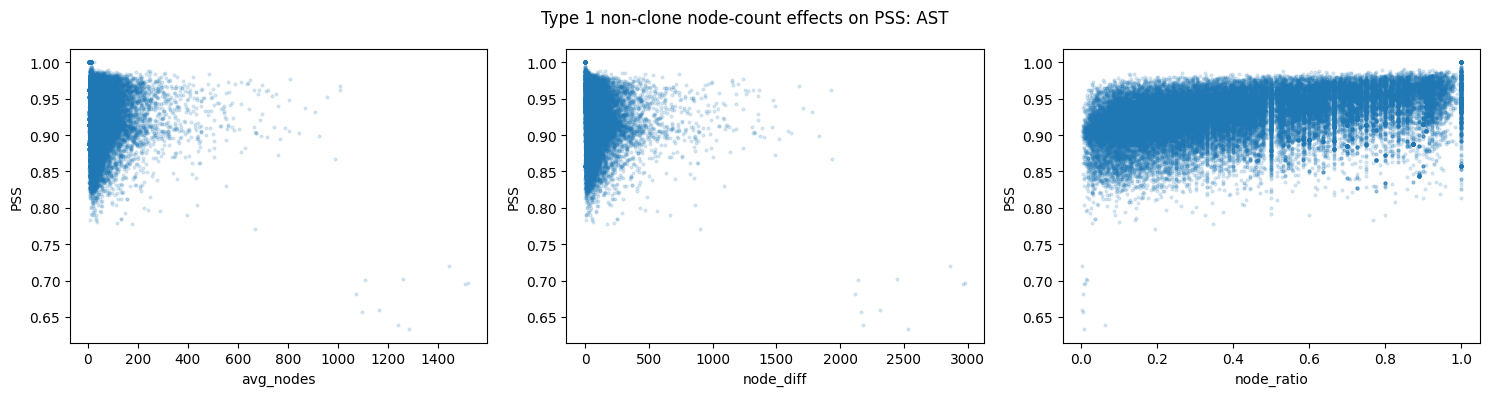

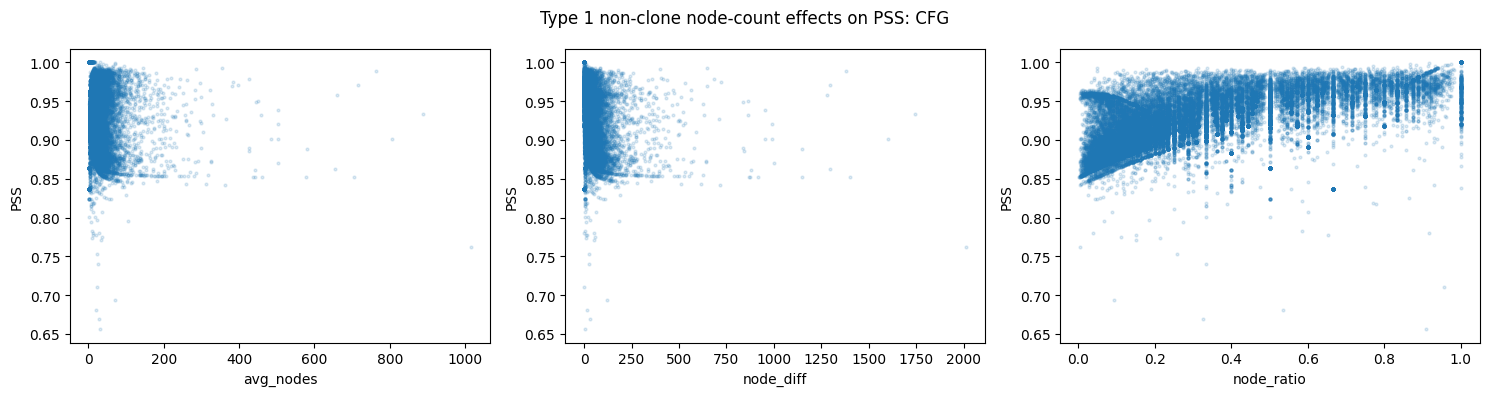

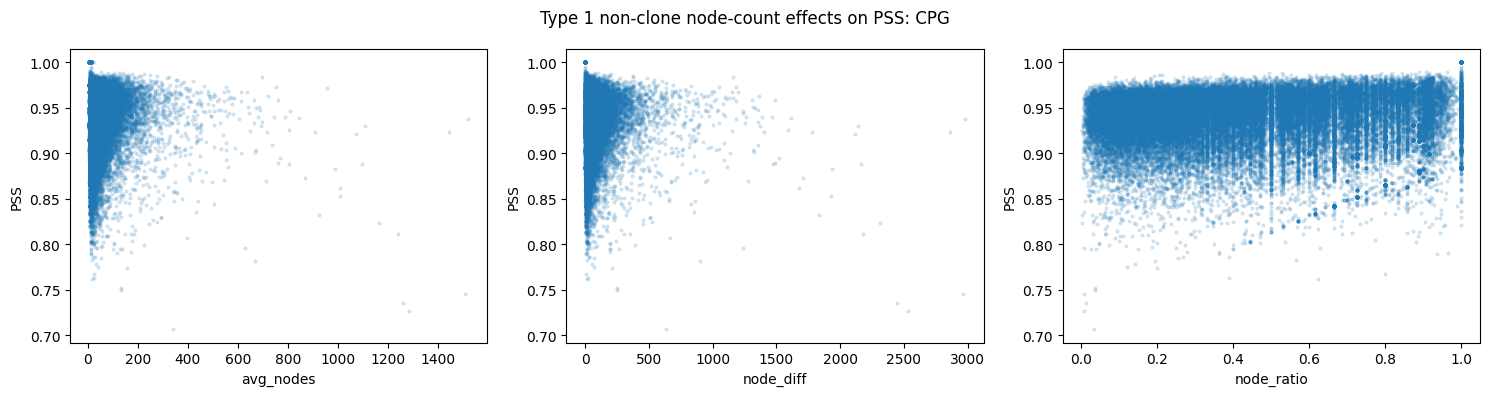

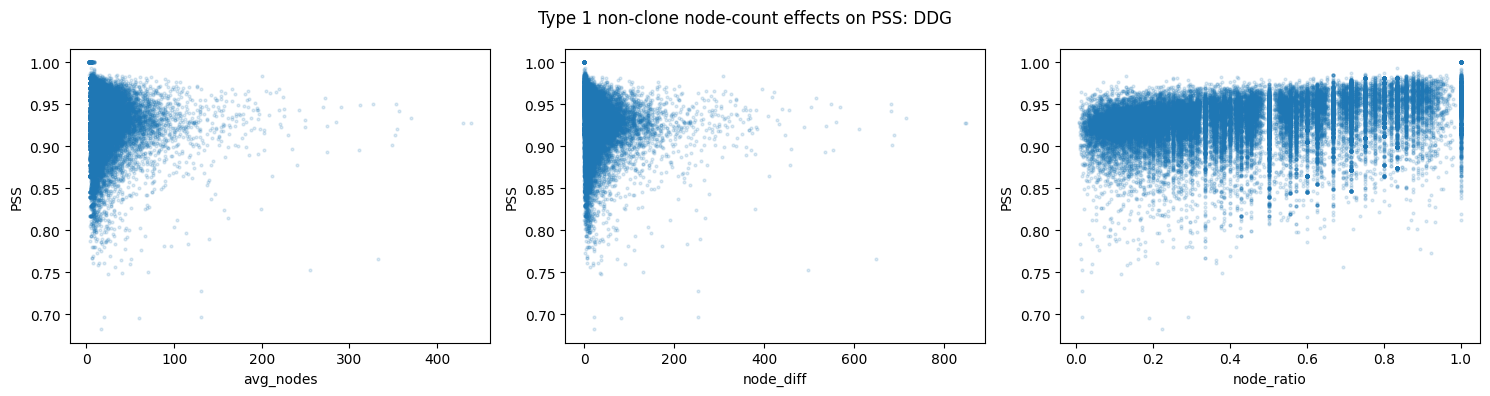

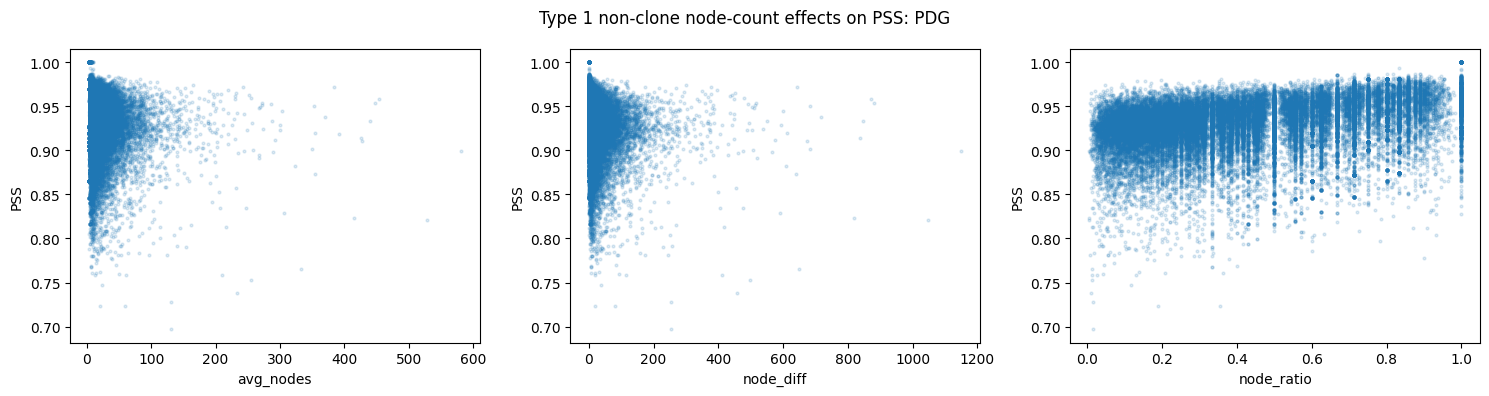

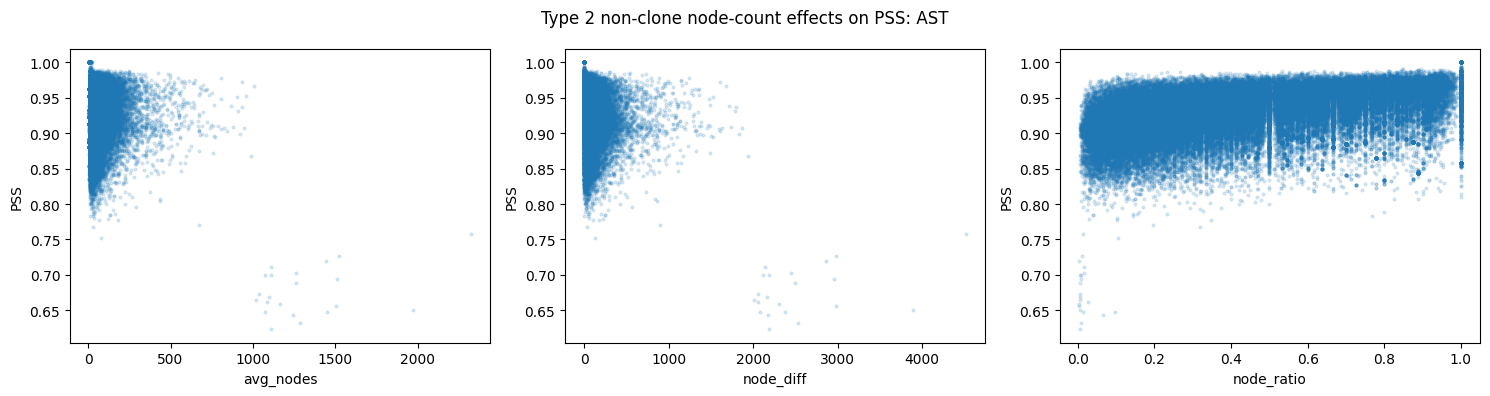

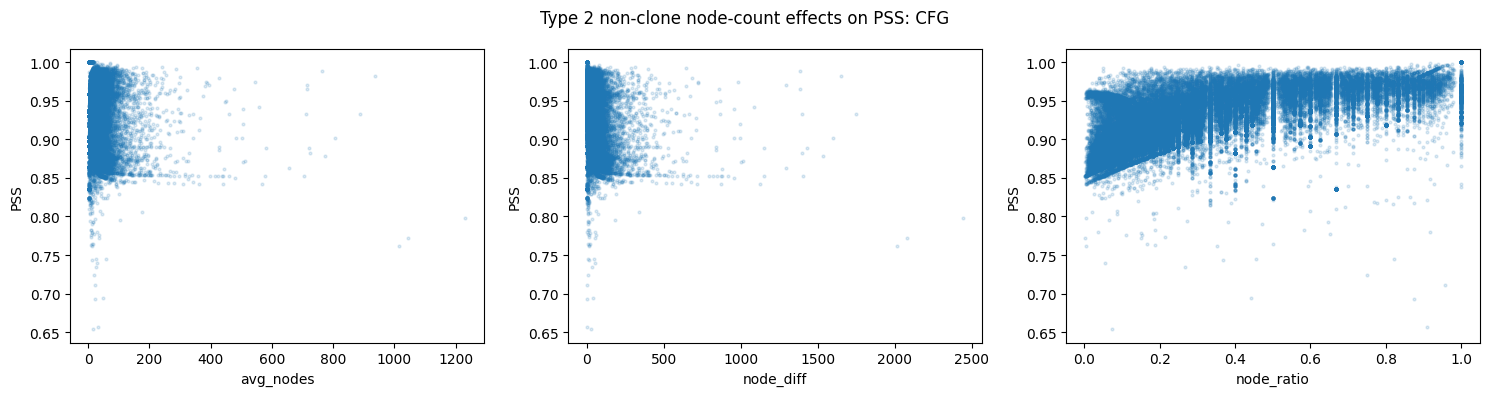

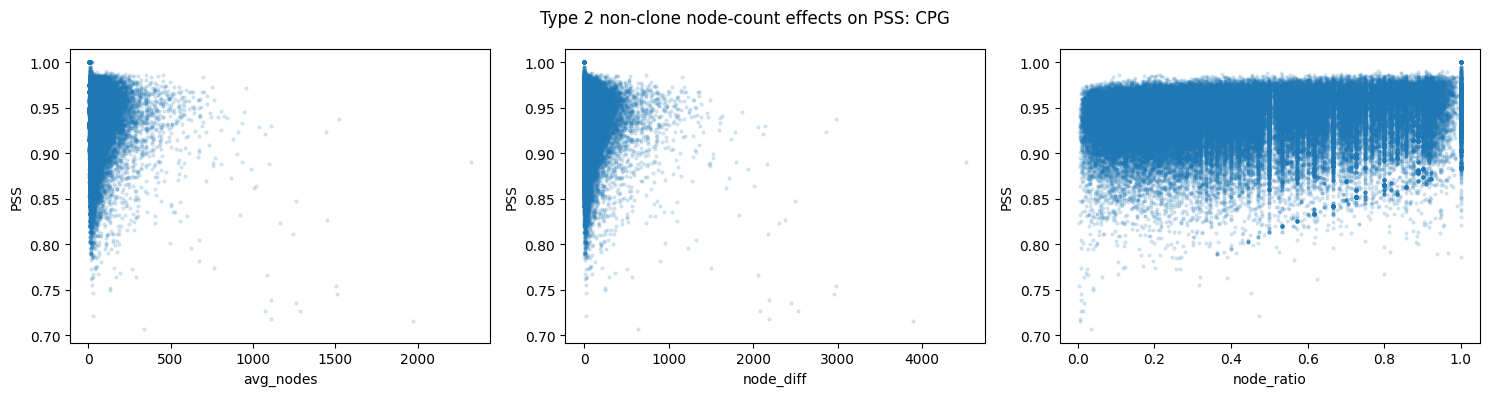

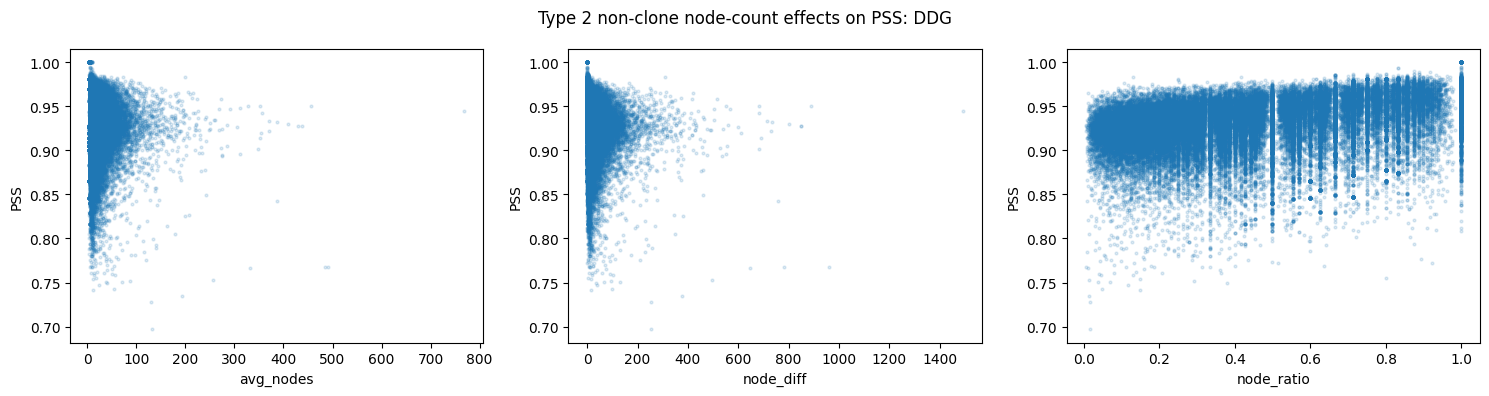

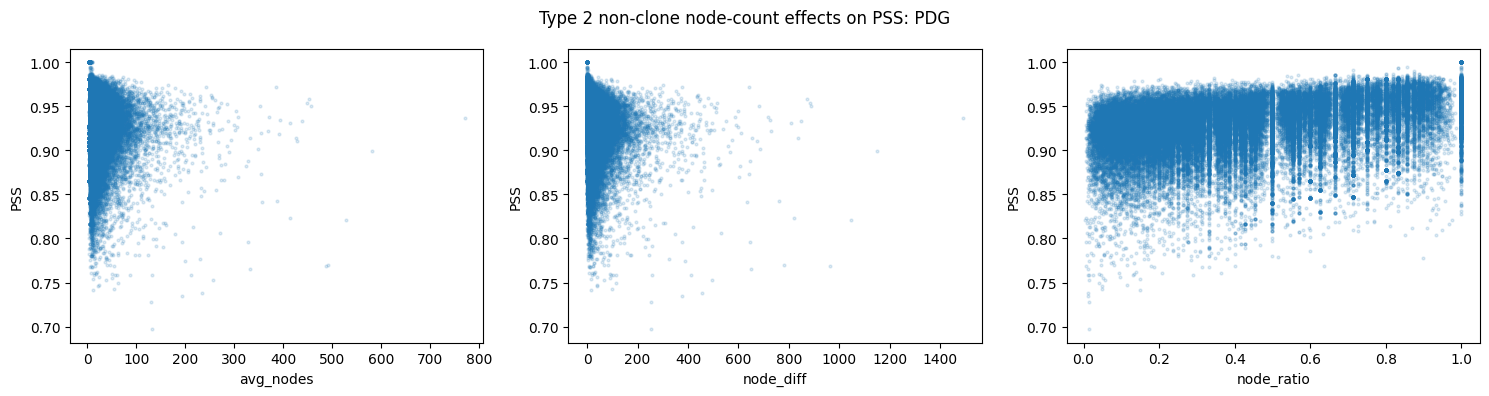

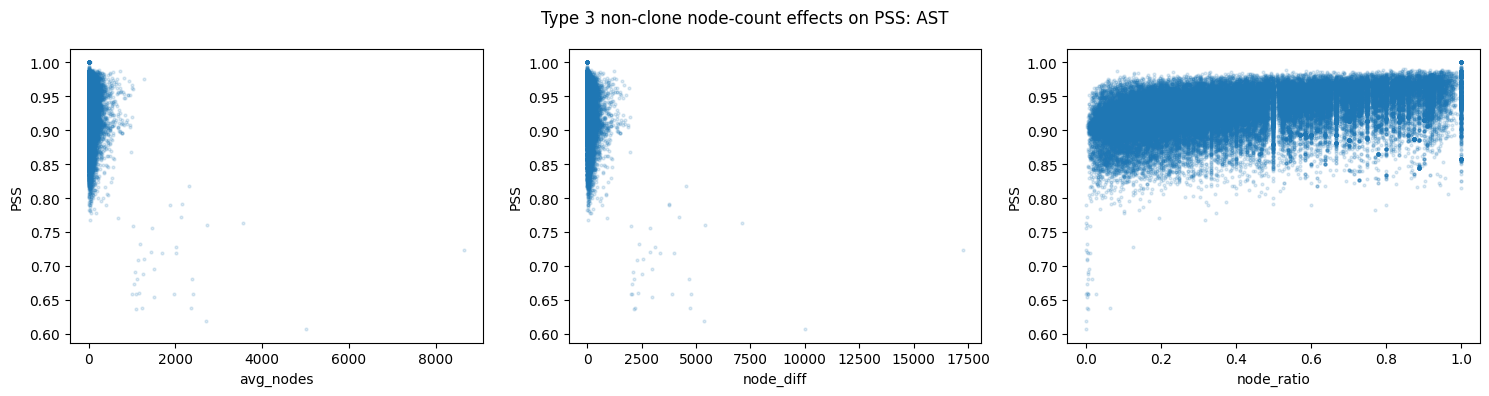

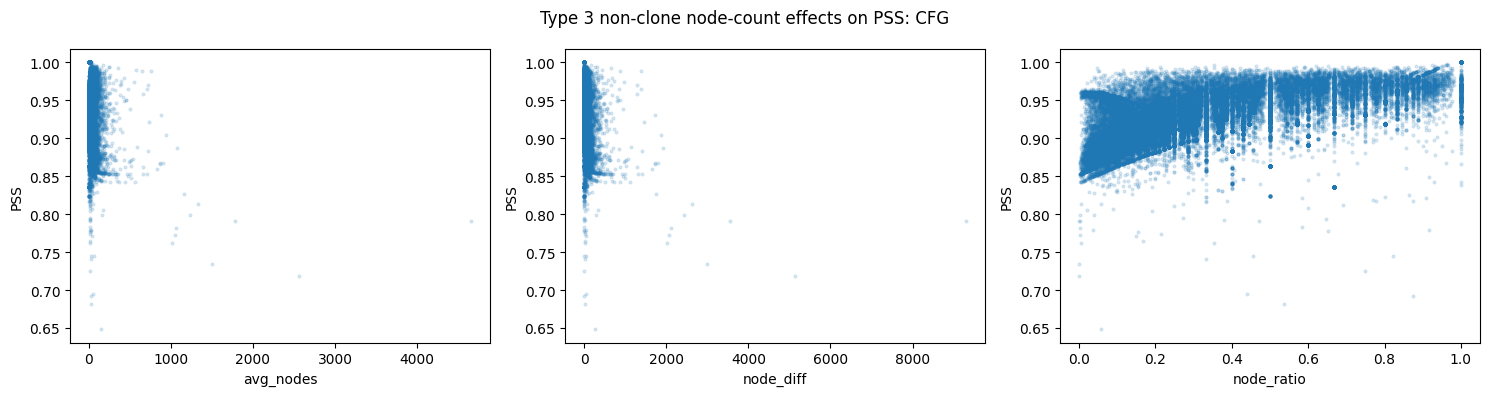

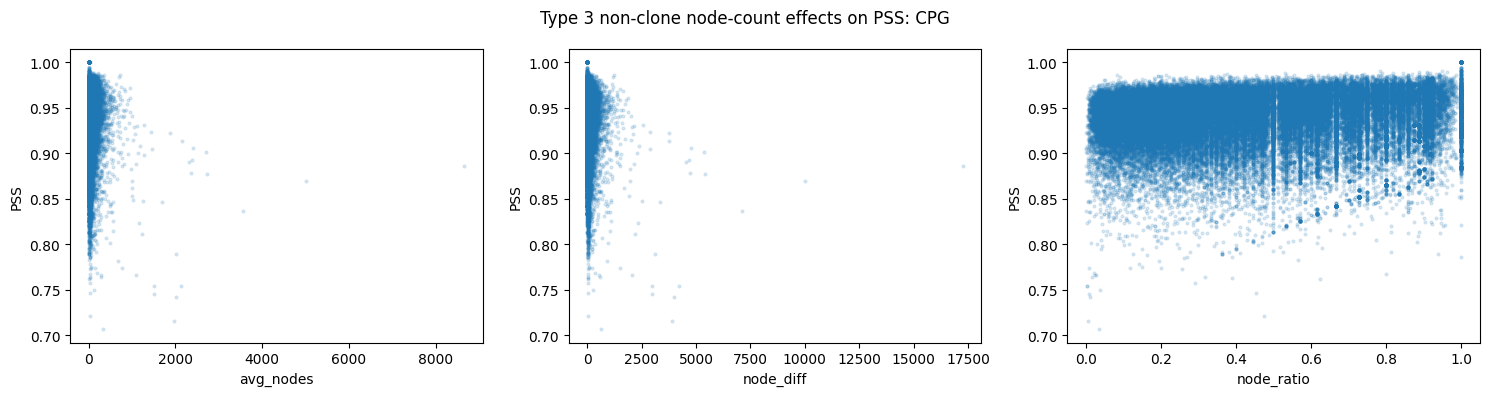

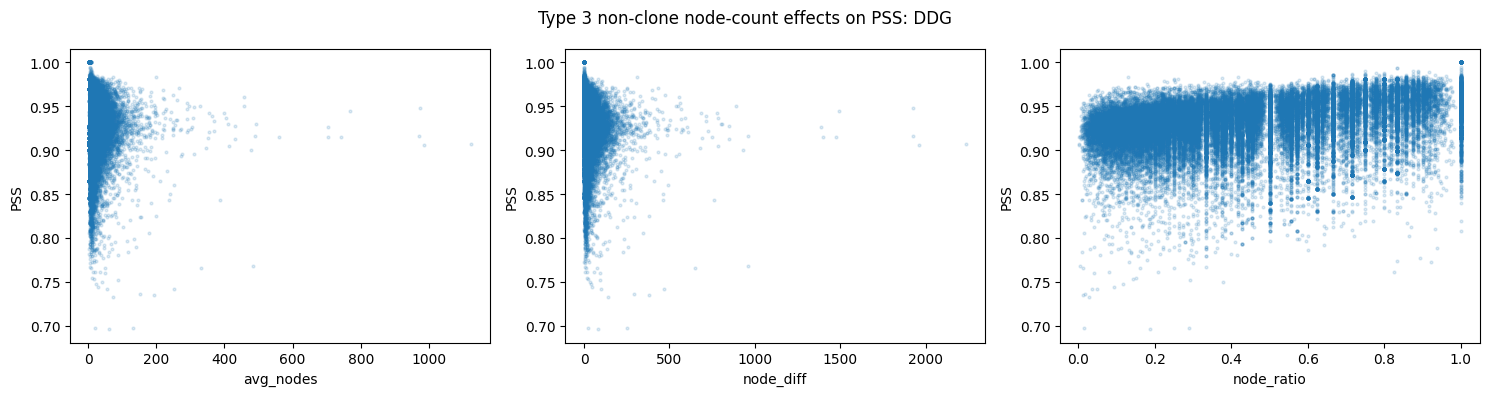

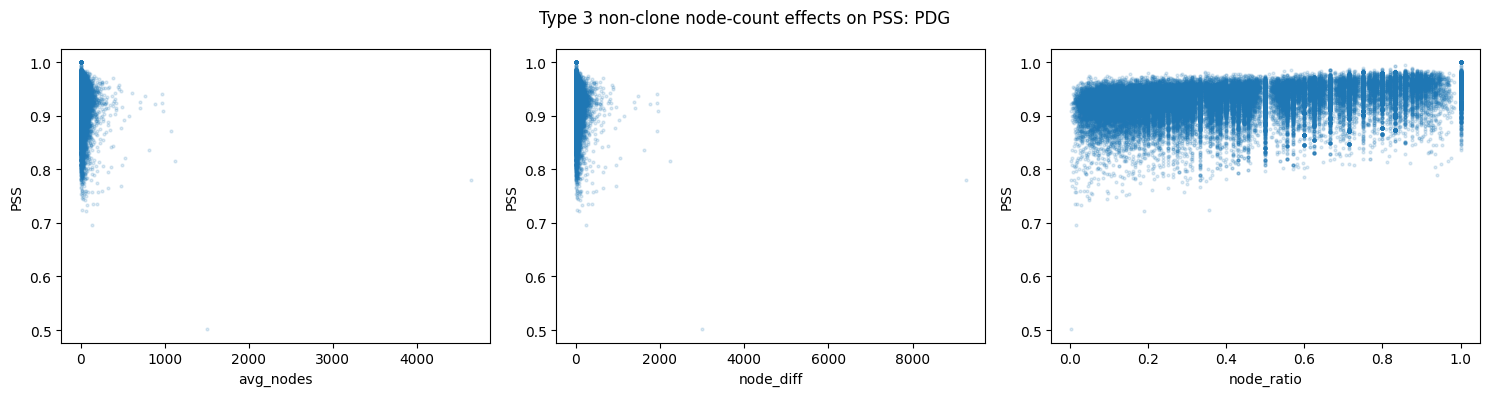

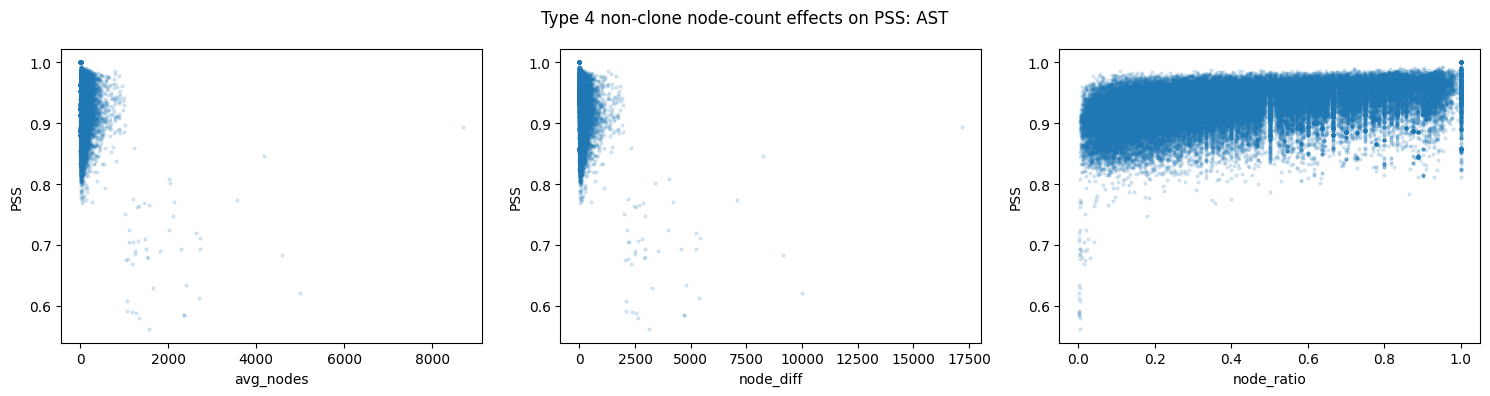

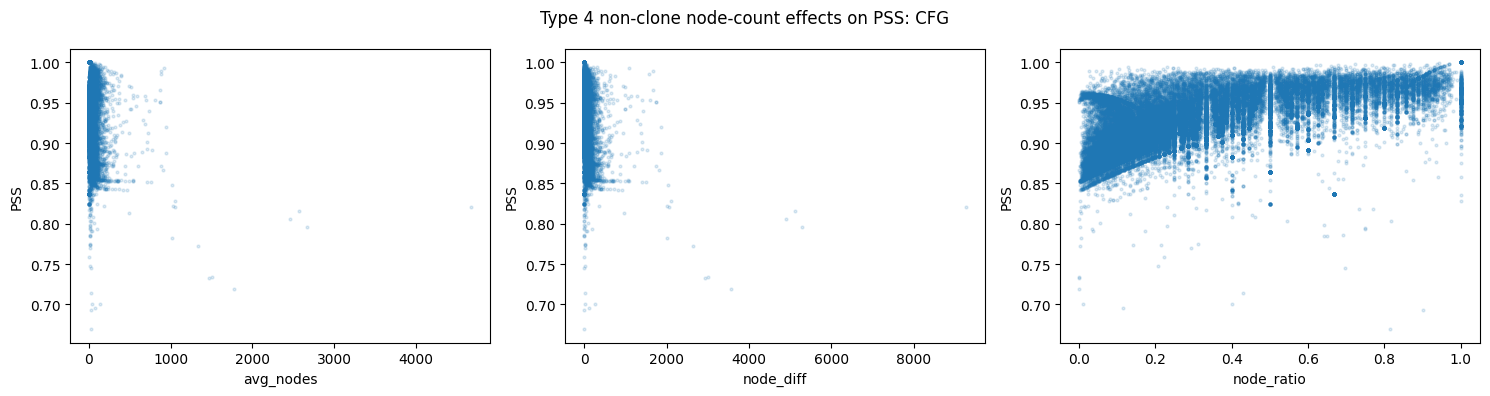

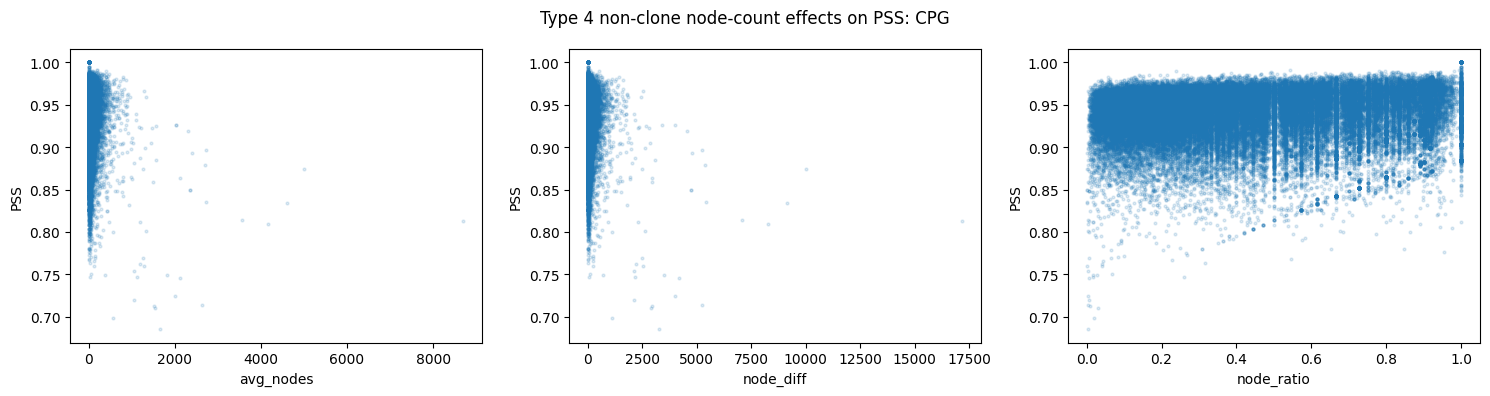

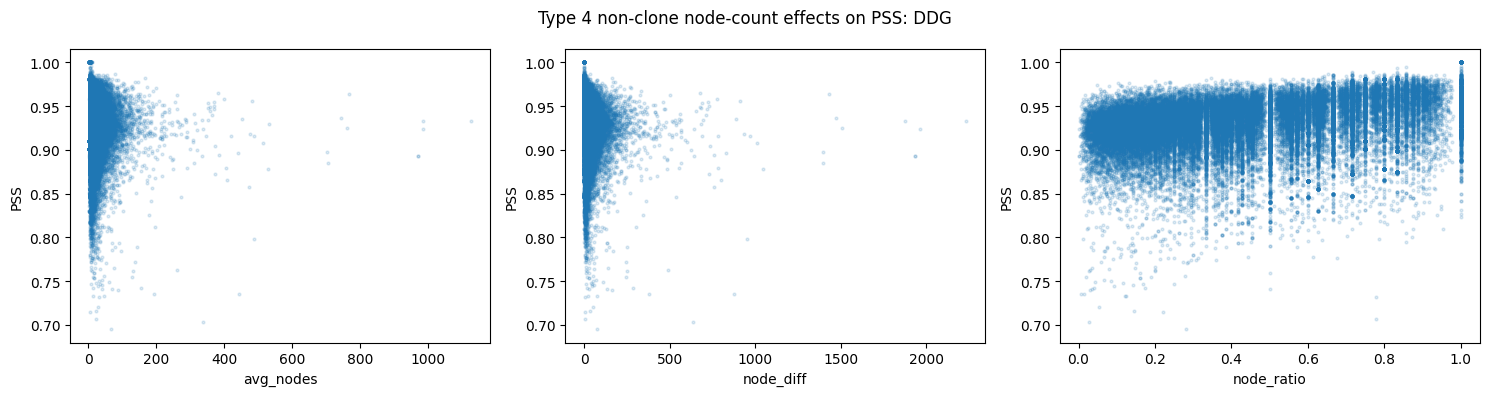

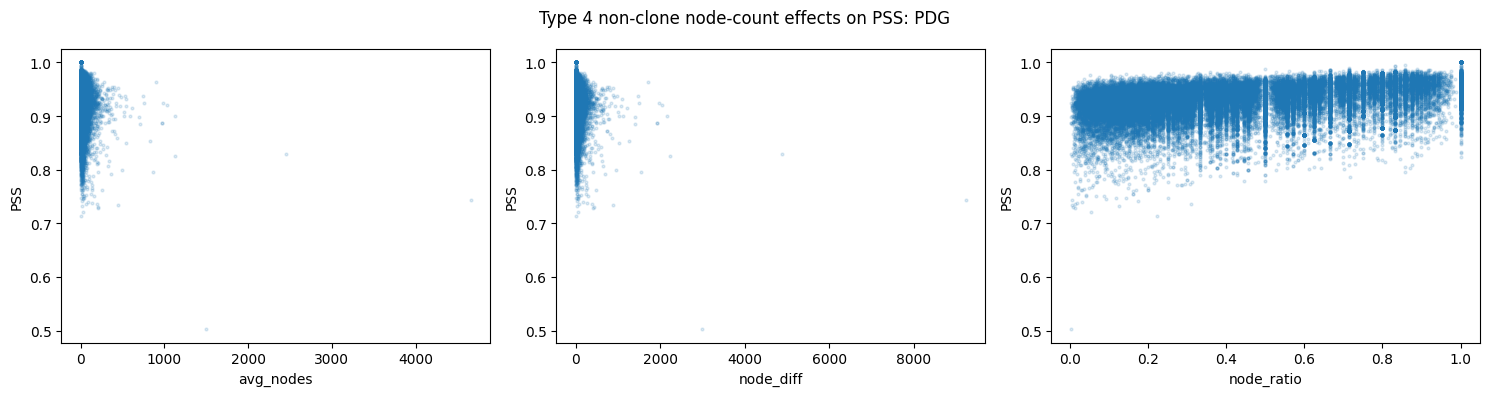

In [6]:
import matplotlib.pyplot as plt

for dataset_type in sorted(node_pss.dataset_type.unique()):
    subset = node_pss[node_pss.dataset_type == dataset_type]
    for graph_type, group in subset.groupby("graph_type"):
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f"Type {dataset_type} non-clone node-count effects on PSS: {graph_type.upper()}")
        for ax, xcol in zip(axes, ["avg_nodes", "node_diff", "node_ratio"]):
            ax.scatter(group[xcol], group["pss"], s=4, alpha=0.15)
            ax.set_xlabel(xcol)
            ax.set_ylabel("PSS")
        plt.tight_layout()
        plt.show()